In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df=pd.read_csv('spam.csv',encoding='latin-1')

In [2]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

In [4]:
df['Unnamed: 2'].isnull().sum()

np.int64(5522)

In [5]:
df['Unnamed: 3'].isnull().sum()

np.int64(5560)

In [6]:
df['Unnamed: 4'].isnull().sum()

np.int64(5566)

In [7]:
df['text']=df['v2']
df['label']=df['v1']

In [8]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4','v1','v2'], inplace=True)

In [9]:
df.head()

,text,label
0,"Go until jurong point, crazy.. Available only ...",ham
1,Ok lar... Joking wif u oni...,ham
2,Free entry in 2 a wkly comp to win FA Cup fina...,spam
3,U dun say so early hor... U c already then say...,ham
4,"Nah I don't think he goes to usf, he lives aro...",ham


In [10]:
df['label'].value_counts(normalize=True)*100

label
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64

In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
X = df['text']
y = le.fit_transform(df['label'])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=5000)
X_train_tf=tfidf.fit_transform(X_train)
X_test_tf=tfidf.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score, f1_score,classification_report

models={
    'LR':LogisticRegression(class_weight='balanced', max_iter=1000),
    'NB': MultinomialNB(),
    'SVM': LinearSVC(class_weight='balanced',random_state=42),
    'RF': RandomForestClassifier(n_estimators=200, random_state=42)
}

result=[]

for name,model in models.items():
    model.fit(X_train_tf,y_train)
    y_pred=model.predict(X_test_tf)
    result.append({
        'Model':name,
        'Accuracy':round(accuracy_score(y_test,y_pred),4),
        'Precision':round(precision_score(y_test,y_pred),4),
        'Recall':round(recall_score(y_test,y_pred),4),
        'F1 Score':round(f1_score(y_test,y_pred),4)

        
    })

result_df=pd.DataFrame(result).sort_values(by='F1 Score',ascending=False)
result_df

,Model,Accuracy,Precision,Recall,F1 Score
2,SVM,0.9883,0.9789,0.9329,0.9553
0,LR,0.9839,0.9456,0.9329,0.9392
3,RF,0.9740,1.0000,0.8054,0.8922
1,NB,0.9641,1.0000,0.7315,0.8450


In [16]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LinearSVC(class_weight='balanced', random_state=42))
])

param_grid = { 
    'tfidf__max_features': [3000, 5000, 8000], 
    'tfidf__ngram_range': [(1, 1), (1, 2)],  
    'clf__C': [0.1, 1, 10], 
}

grid=GridSearchCV(pipeline,param_grid,cv=5,scoring='precision',n_jobs=-1)
grid.fit(X_train,y_train)
print(grid.best_params_)
final_model=grid.best_estimator_
y_pred_final=final_model.predict(X_test)
print(classification_report(y_test,y_pred_final))

{'clf__C': 10, 'tfidf__max_features': 8000, 'tfidf__ngram_range': (1, 1)}
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       966
           1       0.99      0.91      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



[[964   2]
 [ 14 135]]


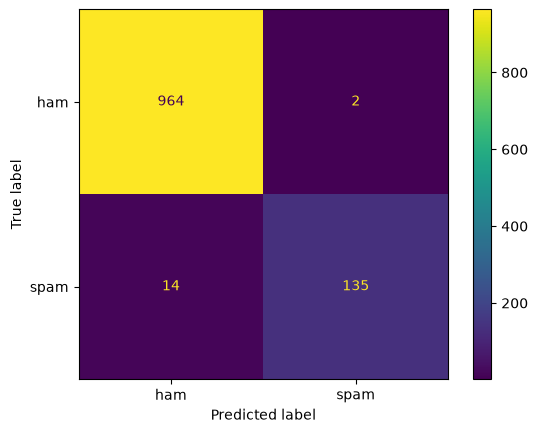

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_final)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
).plot()
plt.show()

In [19]:
import joblib

joblib.dump(final_model, 'spam_classifier.pkl')
joblib.dump(le,'spam_encoder.pkl')

['spam_encoder.pkl']